# Static support boundary

**Question:** How does moving the payload toward a support edge change contact load and stability?

**Bounded procedure / edit here:** Edit the shift samples and the two-second observation duration. Run one finite sweep, then inspect margin and normal-load plots.

**Robot connection:** [measure_support and _support_margin](../../spider/simulation.py) measure support in the robot. The fixture isolates fixed-foot support; it does not prove dynamic recovery.

**Evidence:** Original observations and unanswered work follow unchanged. [Dated findings](../history/2026-08-13-static-support-boundary/README.md) and [interaction record](../history/2026-08-13-static-support-boundary/agent-log.md) retain their provenance. Migration does not establish a new result or demonstrated understanding.

**Setup:** Run the next cell for paths only. Later cells execute experiments; preparation checks do not run them.

In [ ]:
from pathlib import Path
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "spider" / "simulation.py").is_file())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "lab"))


# Static support boundary

## Goal

Test the initial prediction for issue #24: does the signed support margin reach zero before the rear feet unload?

Human prediction: a centered ballast keeps the COM centered; a forward ballast moves it toward the front; beyond the front support edge creates a tipping hazard. The human predicted rear-foot load would increase with forward ballast and estimated a 20–30° forward post-tip pitch.

This notebook is the analysis front end. It invokes the focused headless MuJoCo fixture only to obtain contact loads; it does not open a viewer or make a C-1N capability claim.

## Setup

### Key assumptions

- Three feet remain fixed relative to the torso.
- Only an abstract payload position changes.
- The model is a support-mechanics fixture, not C-1N morphology.
- A two-second rollout is used to let each condition settle or expose loss of rear contact.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from static_support_boundary import PAYLOAD_SHIFT_LIMIT, observe

## Steps

### 1. Sweep payload position

The sweep is coarse by design. Use the first transition to choose a narrower next sweep.

In [2]:
coarse_shifts = np.round(np.linspace(0.0, 0.9, 10), 2)
near_boundary_shifts = np.array([0.92, 0.94, 0.96, 0.98, 1.00, 1.10, 1.20])
shifts = np.concatenate((coarse_shifts, near_boundary_shifts))
records = []
for shift in shifts:
    observation = observe(float(shift), seconds=2.0)
    loads = observation['foot_normal_loads_n']
    records.append({
        'payload_shift_m': shift,
        'support_margin_m': observation['support_margin_m'],
        'front_load_n': loads[0],
        'rear_left_load_n': loads[1],
        'rear_right_load_n': loads[2],
        'minimum_rear_load_n': min(loads[1:]),
        'com_x_m': observation['com_world_xy_m'][0],
        'roll_deg': np.rad2deg(observation['torso_roll_rad']),
        'pitch_deg': np.rad2deg(observation['torso_pitch_rad']),
        'standing_metric_pass': bool(observation['standing_metric_pass']),
    })
results = pd.DataFrame(records)
results

,payload_shift_m,support_margin_m,front_load_n,rear_left_load_n,rear_right_load_n,minimum_rear_load_n,com_x_m,roll_deg,pitch_deg,standing_metric_pass
0,0.00,0.130408,7.599474,5.765013,5.765013,5.765013,-0.001359,-3.072152e-18,0.005018,True
1,0.10,0.116914,8.792316,5.168592,5.168592,5.168592,0.029828,1.233045e-17,0.009814,True
2,0.20,0.103424,9.984834,4.572333,4.572333,4.572333,0.061006,-1.787620e-16,0.014506,True
3,0.30,0.089937,11.177012,3.976244,3.976244,3.976244,0.092175,-1.586728e-16,0.019086,True
4,0.40,0.076454,12.368841,3.380329,3.380329,3.380329,0.123335,2.336176e-17,0.023554,True
5,0.50,0.062976,13.560317,2.784591,2.784591,2.784591,0.154485,-1.639864e-16,0.027907,True
6,0.60,0.049501,14.751442,2.189028,2.189028,2.189028,0.185626,1.416759e-16,0.032147,True
7,0.70,0.036030,15.942219,1.593639,1.593639,1.593639,0.216757,5.748162e-17,0.036276,True
8,0.80,0.022564,17.132655,0.998421,0.998421,0.998421,0.247879,9.481841e-17,0.040294,True
9,0.90,0.009101,18.322758,0.403370,0.403370,0.403370,0.278993,3.048139e-18,0.044205,True


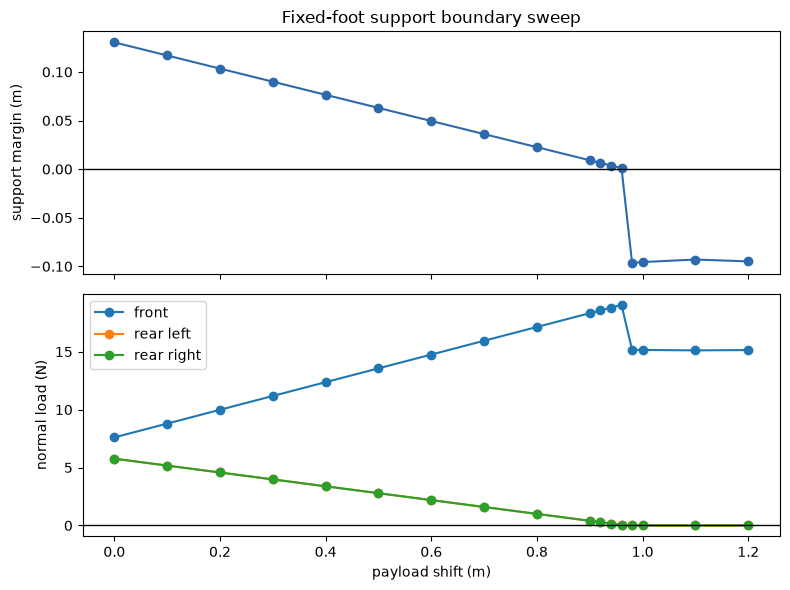

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(results.payload_shift_m, results.support_margin_m, marker='o', color='#2f69ad')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_ylabel('support margin (m)')
axes[0].set_title('Fixed-foot support boundary sweep')
axes[1].plot(results.payload_shift_m, results.front_load_n, marker='o', label='front')
axes[1].plot(results.payload_shift_m, results.rear_left_load_n, marker='o', label='rear left')
axes[1].plot(results.payload_shift_m, results.rear_right_load_n, marker='o', label='rear right')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('payload shift (m)')
axes[1].set_ylabel('normal load (N)')
axes[1].legend()
fig.tight_layout()

## Checks

Fixture standing metric: all three feet have more than `0.001 N` normal load after a two-second rollout, and both roll and pitch remain within `±5°`. This is a test-bench metric, not the future C-1N STAND criterion.

A fixed-foot quasi-static boundary should pair an exhausted support margin with unloading of the limiting rear contact. The coarse sweep can bracket the transition, but it cannot establish an exact threshold.

In [4]:
last_positive_margin = results.loc[results.support_margin_m > 0].tail(1)
first_unloaded_rear = results.loc[results.minimum_rear_load_n <= 1e-3].head(1)
print('Last sampled positive margin:')
display(last_positive_margin)
print('First sampled unloaded rear contact:')
display(first_unloaded_rear)

Last sampled positive margin:


,payload_shift_m,support_margin_m,front_load_n,rear_left_load_n,rear_right_load_n,minimum_rear_load_n,com_x_m,roll_deg,pitch_deg,standing_metric_pass
12,0.96,0.001007,19.038238,0.045629,0.045629,0.045629,0.297705,1.073486e-16,0.046506,True


First sampled unloaded rear contact:


,payload_shift_m,support_margin_m,front_load_n,rear_left_load_n,rear_right_load_n,minimum_rear_load_n,com_x_m,roll_deg,pitch_deg,standing_metric_pass
13,0.98,-0.096543,15.158607,0.0,0.0,0.0,0.545929,2.489353e-14,23.588235,False


## Takeaways

The centered case passes the fixture metric. At `shift = 0.96 m`, the margin is `+0.0010 m` and each rear foot carries `0.046 N`; it also passes. At `0.98 m`, both rear contacts are unloaded, the metric fails, and pitch is `+23.6°` after tipping.

The observed model corrects one prediction: forward ballast increases the front-foot load and decreases rear-foot load. The COM-location and forward-pitch predictions held. The support-margin and rear-unloading events are bracketed in the same `0.96–0.98 m` interval.

A later C-1N experiment must separately measure changing support geometry and contact set during gait; this fixed-foot fixture cannot answer that dynamic question.

## Related bounded experiment: a torque-supported tripod

**Question:** What changes when the desired body position moves over three articulated support legs?

**Edit here:** body shift, squat drop, and finite duration. This reuses the original [tripod controller](../tripod_static_support.py). It reports body position, target position, and allocated support forces. These are controller allocations, not interchangeable with measured contact loads in the fixed-foot sweep above.

The original [Jacobian/support findings](../history/2026-08-09-jacobians-task-space/README.md) include the useful failures and diagrams. C-1N uses a support-gated target-angle correction; this tripod torque controller remains an isolated experiment. A successful tripod sample would not advance the robot's STAND claim.

In [ ]:
from types import SimpleNamespace
import mujoco
from lab import tripod_static_support as tripod

body_shift = 0.0
squat_drop = 0.0
seconds = 6.0
assert 0 < seconds <= 60
model = tripod.make_model()
data = mujoco.MjData(model)
tripod.initialize(model, data)
tripod.run(model, data, SimpleNamespace(body_shift=body_shift, squat_drop=squat_drop,
                                     headless=True, duration=seconds))

Compare the allocated forces with the contact-load question above before making a stability claim. The original viewer can be launched with `python -m lab.tripod_static_support --body-shift 0 --squat-drop 0`; it is a live rerun. No new result has been recorded during migration.